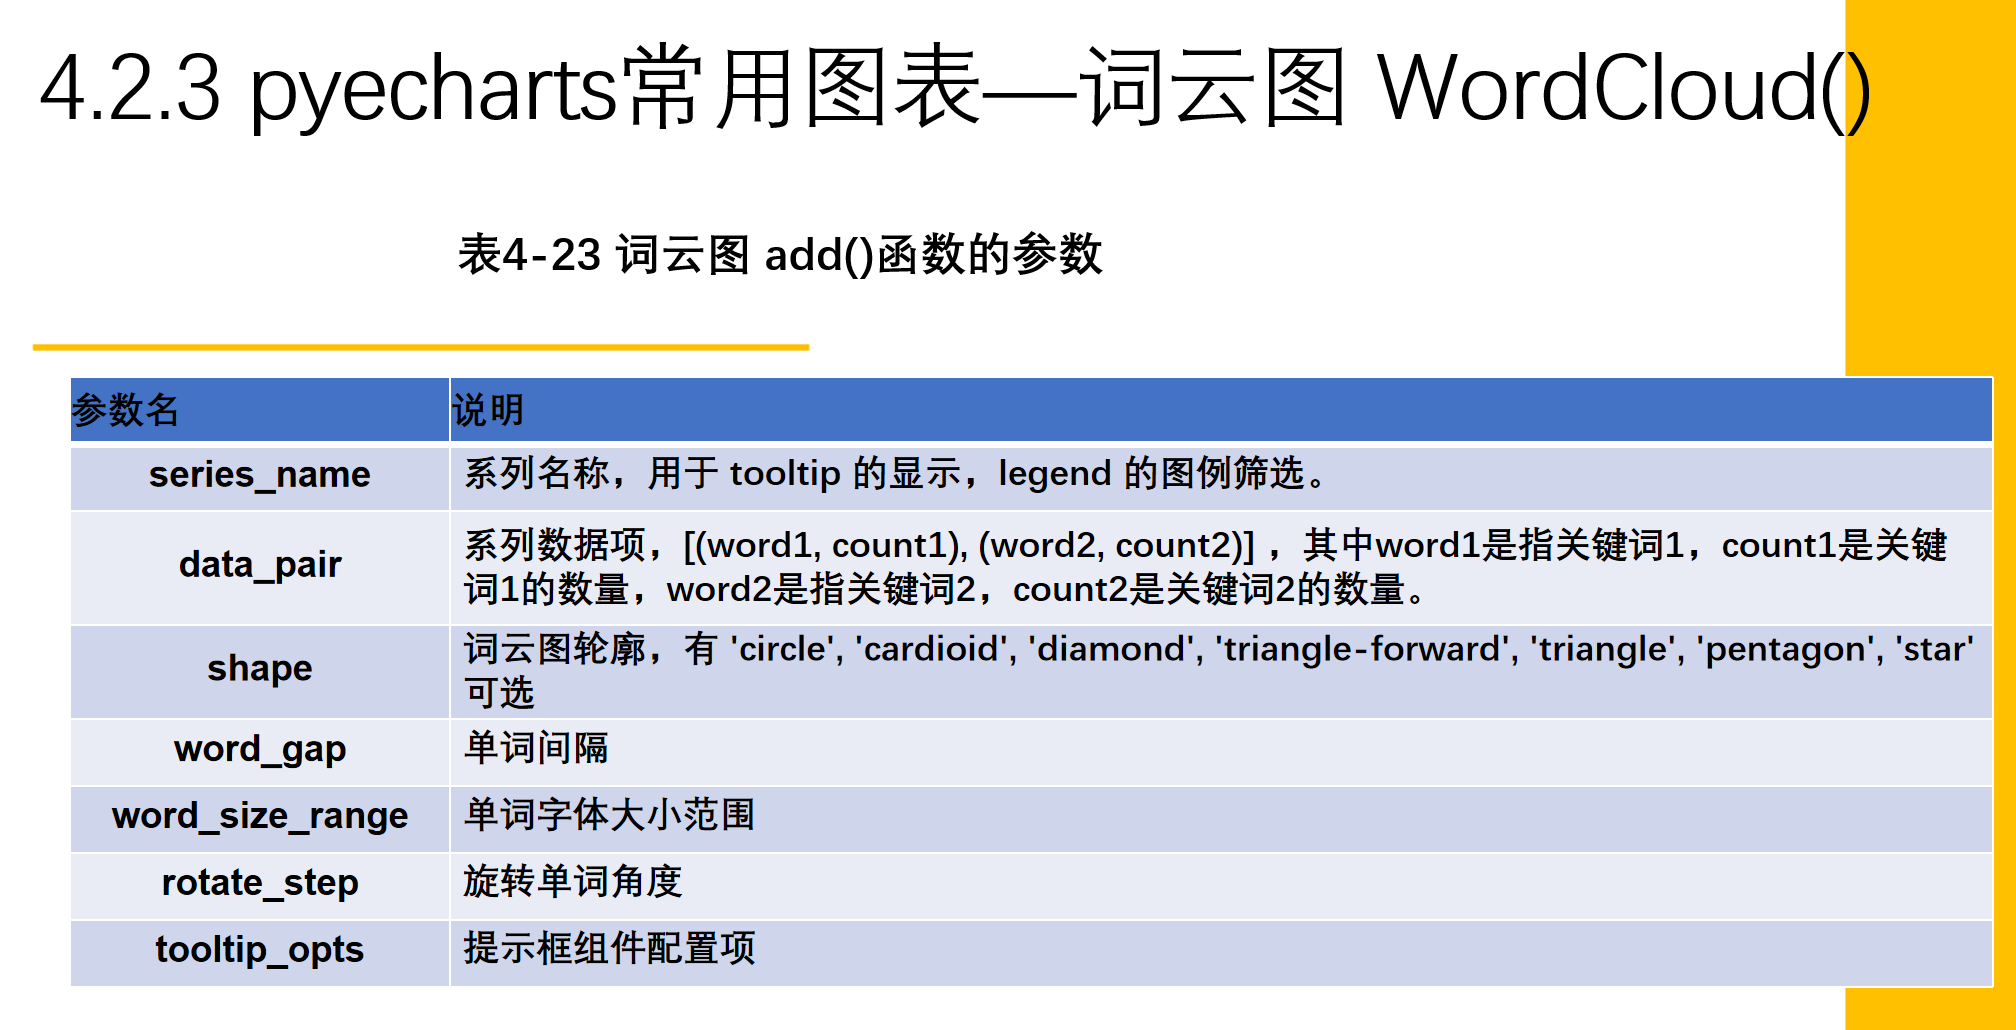

In [1]:
#CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB
from pyecharts_exporter import display_chart, get_chart_urls
from pyecharts import options as opts
from pyecharts.charts import WordCloud

words = [
    ("牛肉面", 7800),("黄河", 6181),
    ("《读者》杂志", 4386), ("甜胚子", 3055),
    ("甘肃省博物馆", 2055),("莫高窟", 8067),("兰州大学", 4244),
    ("西北师范大学", 1868),("中山桥", 3484),
    ("月牙泉", 1112),("五泉山", 980),
    ("五彩丹霞", 865),("黄河母亲", 847),("崆峒山",678),
    ("羊皮筏子", 1582),("兴隆山",868),
    ("兰州交通大学", 1555),("白塔山", 2550),("五泉山", 2550)]
c = (
    WordCloud()
    .add("", words, word_size_range=[20,60], shape='')  #shape参数的默认形状是 "circle" 
    .set_global_opts(title_opts=opts.TitleOpts(title="WordCloud-基本示例",pos_left='center'))
)

print(get_chart_urls(c))
display_chart(c)

{'dependencies': ['echarts', 'echarts-wordcloud'], 'cdn_urls': ['https://assets.pyecharts.org/assets/v6/echarts.min.js', 'https://assets.pyecharts.org/assets/v6/echarts-wordcloud.min.js'], 'html_tags': '<script src="https://assets.pyecharts.org/assets/v6/echarts.min.js"></script>\n<script src="https://assets.pyecharts.org/assets/v6/echarts-wordcloud.min.js"></script>', 'theme_detected': 'white'}


## 词云实例

In [2]:
from pyecharts.globals import CurrentConfig, NotebookType
#CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

# 引入pyecharts相关的包，并引入构建词云需要的包、引入读取csv文件需要的pandas包
from pyecharts import options as opts
from pyecharts.charts import WordCloud
from pyecharts.globals import SymbolType
import pandas as pd

# 读取岗位数据，统计不同岗位名称的词频
df= pd.read_excel('data/orders.xlsx')
df

,编号,日期,门店,支付方式,到款日期,分类,客户编号,姓名,客户类别,所属市,...,品名,产品大类,商品类型,金额,data1,data2,Unnamed: 19,经手人,类别,Unnamed: 22
0,CN-2017-100001,2017-01-01,海恒店,信用卡,2017-01-07,3,Cust-18715,邢宁,公司,常德,...,诺基亚_智能手机_整包,技术,电话,1725.360,3,0.0,68.880,王倩倩,0,2017
1,CN-2017-100002,2017-01-01,庐江路,信用卡,2017-01-07,6,Cust-10555,彭博,公司,沈阳,...,Eaton_令_每包_12_个,办公用品,纸张,572.880,4,0.0,183.120,郝杰,0,2017
2,CN-2017-100003,2017-01-03,定远路店,微信,2017-01-07,6,Cust-15985,薛磊,消费者,湛江,...,施乐_计划信息表_多色,办公用品,纸张,304.920,3,0.0,97.440,王倩倩,0,2017
3,CN-2017-100004,2017-01-03,众兴店,信用卡,2017-01-07,6,Cust-15985,薛磊,消费者,湛江,...,Hon_椅垫_可调,家具,椅子,243.684,1,0.1,108.304,王倩倩,0,2017
4,CN-2017-100005,2017-01-03,燎原店,信用卡,2017-01-08,3,Cust-12490,洪毅,公司,宁波,...,Cuisinart_搅拌机_白色,办公用品,器具,729.456,4,0.4,-206.864,杨洪光,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9742,CN-2019-103615,2019-12-31,海恒店,信用卡,2019-12-31,1,Cust-19345,洪强,公司,唐山,...,Hon_折叠椅_红色,家具,椅子,1899.800,5,0.0,702.800,张怡莲,1,2019
9743,CN-2019-103616,2019-12-31,庐江路,信用卡,2019-12-31,0,Cust-19345,洪强,公司,唐山,...,Enermax_闪存驱动器_实惠,技术,配件,193.760,1,0.0,83.300,张怡莲,1,2019
9744,CN-2019-103617,2019-12-31,金寨店,支付宝,2019-12-31,1,Cust-19345,洪强,公司,唐山,...,Avery_装订机_透明,办公用品,装订机,57.680,1,0.0,20.160,张怡莲,1,2019
9745,CN-2019-103618,2019-12-31,众兴店,支付宝,2019-12-31,0,Cust-19345,洪强,公司,唐山,...,Cuisinart_烤面包机_黑色,办公用品,器具,246.820,1,0.0,96.180,张怡莲,1,2019


In [3]:
a_name = list(df.商品类型.value_counts().index)
a_count = list(df.商品类型.value_counts())
# 将词频数据转换成构建词云需要的格式
a = list(zip(a_name,a_count))
a_name
df.商品类型.value_counts()

商品类型
装订机    861
椅子     844
收纳具    777
信封     604
书架     597
用具     589
用品     588
系固件    574
电话     570
复印机    555
器具     550
标签     545
配件     543
纸张     542
美术     527
设备     311
桌子     170
Name: count, dtype: int64

In [5]:
# 使用WordCloud词云模块，链式调用配置，最终生成html文件
c1 = (
    WordCloud()
    .add("", a, word_size_range=[10, 50], shape='SymbolType.DIAMOND')
    .set_global_opts(
        title_opts=opts.TitleOpts(title="销售商品类型关键词词云",
                                  title_textstyle_opts = opts.TextStyleOpts(
                                      font_family='Microsoft YaHei',
                                      font_weight='bold',
                                      font_size =30,
                                      color="midnightblue"))
    )
)

display_chart(c1)

